# Electricity Demand Forecasting with SARIMA

**Dataset:** UCI Electricity Load Diagrams 2011–2014  
**Citation:** Trindade, A. (2015), *ElectricityLoadDiagrams20112014*, UCI Machine Learning Repository, DOI: [10.24432/C58C86](https://doi.org/10.24432/C58C86)  
**Target:** Aggregate daily electricity consumption across 370 client meters (kWh)  
**Methodology:** Seasonal Autoregressive Integrated Moving Average (SARIMA / SARIMAX) with weekly seasonality ($m=7$), walk-forward rolling validation, sample-by-sample inspection, and benchmarking against Naive & Seasonal Naive baselines.

# 1. Setup & Environment

Import essential scientific and time-series packages, configure visualization styles and plotting parameters.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pmdarima as pm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10
})
print('All libraries loaded successfully.')

All libraries loaded successfully.


# 2. Dataset Facts & Problem Formulation

From the UCI repository:
- 370 client electricity meters (`MT_001` through `MT_370`) recorded at 15-minute intervals between 2011 and 2014 (~140,256 rows).
- Values recorded in **kW per 15-minute interval**. Divide by 4 ($\times 0.25$) to obtain energy in **kWh**:
$$\text{Energy (kWh)} = \frac{\text{Power (kW)}}{4}$$
- Many clients joined gradually after 2011 (showing zeroes prior to start).
- **Day count correction:** The raw text file ends at `2015-01-01 00:00:00`. Filtering strictly between `2012-01-01 00:00:00` and `2014-12-31 23:45:00` discards the trailing single-reading timestamp and ensures an exact sequence of **1,096 complete days**.
- **Aggregation decision:** Rather than fitting high-frequency 15-minute intervals ($m=96$) on 140,000 points, we aggregate across all 370 client meters into daily total energy consumption, yielding a well-behaved series with weekly seasonality ($m=7$).

In [2]:
DATA_FILE = 'LD2011_2014.txt'
DAILY_CSV = 'daily_electricity_total.csv'

if os.path.exists(DAILY_CSV):
    print(f'Loading preprocessed daily series from {DAILY_CSV}...')
    daily_total = pd.read_csv(DAILY_CSV, index_col=0, parse_dates=True)['total_kwh']
    daily_total.index.freq = 'D'
    print(f'Loaded {len(daily_total)} daily records from {daily_total.index.min().date()} to {daily_total.index.max().date()}')
else:
    print(f'Processing raw data from {DATA_FILE}...')
    df_raw = pd.read_csv(
        DATA_FILE,
        sep=';',
        decimal=',',
        index_col=0,
        parse_dates=True,
        low_memory=False
    )
    df_raw.columns = df_raw.columns.str.strip().str.strip('"')
    # Filter strictly to full 2012-2014 calendar window (excluding trailing partial Jan 1 00:00 reading)
    df_kwh = df_raw.loc['2012-01-01':'2014-12-31 23:45'] * 0.25
    daily_total = df_kwh.sum(axis=1).resample('D').sum()
    daily_total.name = 'total_kwh'
    daily_total.index.freq = 'D'
    daily_total.to_frame().to_csv(DAILY_CSV)

assert len(daily_total) == 1096, f'Expected 1,096 days, got {len(daily_total)}'
print(f'Exact 1,096 days verified: {daily_total.index.min().date()} to {daily_total.index.max().date()}')
daily_total.describe()

Loading preprocessed daily series from daily_electricity_total.csv...
Loaded 1096 daily records from 2012-01-01 to 2014-12-31
Exact 1,096 days verified: 2012-01-01 to 2014-12-31


count    1.096000e+03
mean     5.275556e+06
std      8.602801e+05
min      2.677286e+06
25%      4.577243e+06
50%      4.956394e+06
75%      5.950681e+06
max      7.542149e+06
Name: total_kwh, dtype: float64

# 3. Data Integrity & Anomaly Check

We inspect missing values and verify index continuity. Note: Genuine holiday drops (Christmas, New Year) reflect real reductions in commercial and industrial load and are deliberately preserved rather than artificially smoothed.

In [3]:
print(f'Total missing (NaN) values: {daily_total.isna().sum()}')
print(f'Frequency of DatetimeIndex : {daily_total.index.freq}')
print(f'Min daily load: {daily_total.min():,.0f} kWh (on {daily_total.idxmin().date()})')
print(f'Max daily load: {daily_total.max():,.0f} kWh (on {daily_total.idxmax().date()})')

Total missing (NaN) values: 0
Frequency of DatetimeIndex : <Day>
Min daily load: 2,677,286 kWh (on 2014-12-25)
Max daily load: 7,542,149 kWh (on 2013-07-06)


# 4. Exploratory Data Analysis (EDA)

Visualizing the aggregate daily consumption across the full period, zooming into weekly patterns, and inspecting day-of-week and monthly distributions.

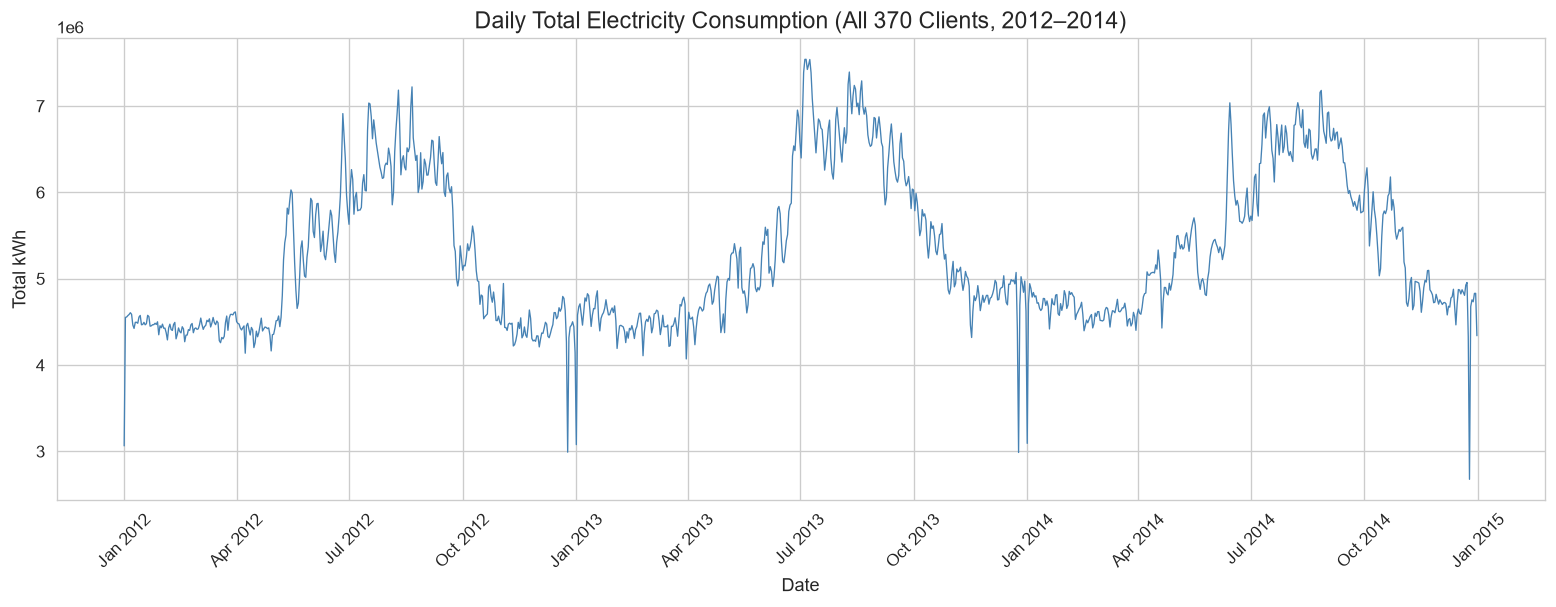

In [4]:
# Full daily series
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_total.index, daily_total.values, linewidth=0.8, color='steelblue')
ax.set_title('Daily Total Electricity Consumption (All 370 Clients, 2012–2014)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total kWh')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.show()

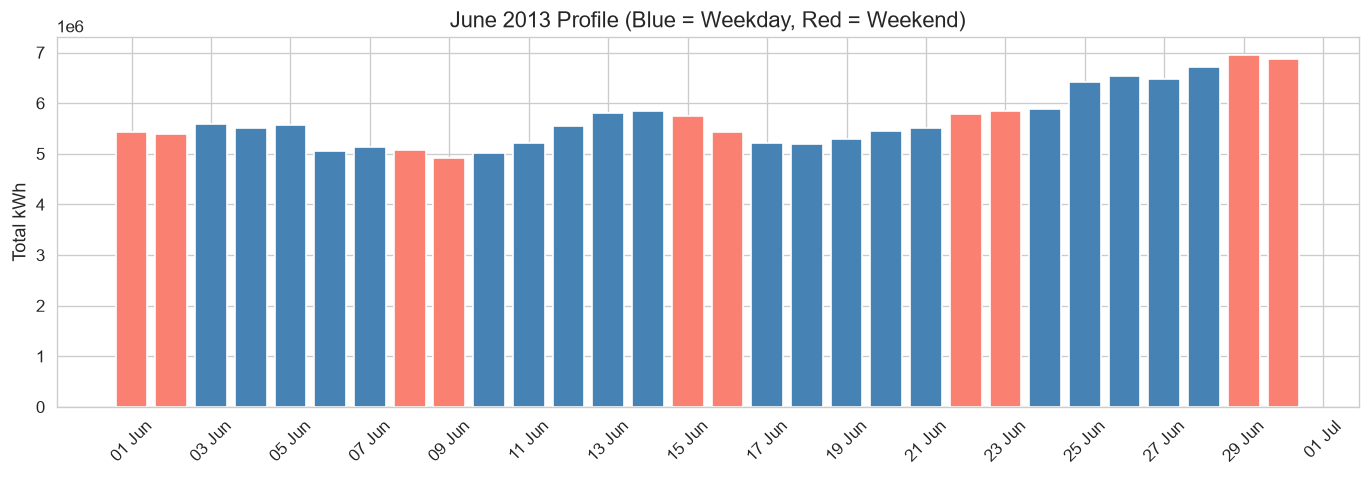

In [5]:
# Zoomed Month: Weekday vs Weekend Profile (June 2013)
zoom_month = daily_total.loc['2013-06']
colors = ['salmon' if d.weekday() >= 5 else 'steelblue' for d in zoom_month.index]
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(zoom_month.index, zoom_month.values, color=colors, width=0.8)
ax.set_title('June 2013 Profile (Blue = Weekday, Red = Weekend)')
ax.set_ylabel('Total kWh')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.show()

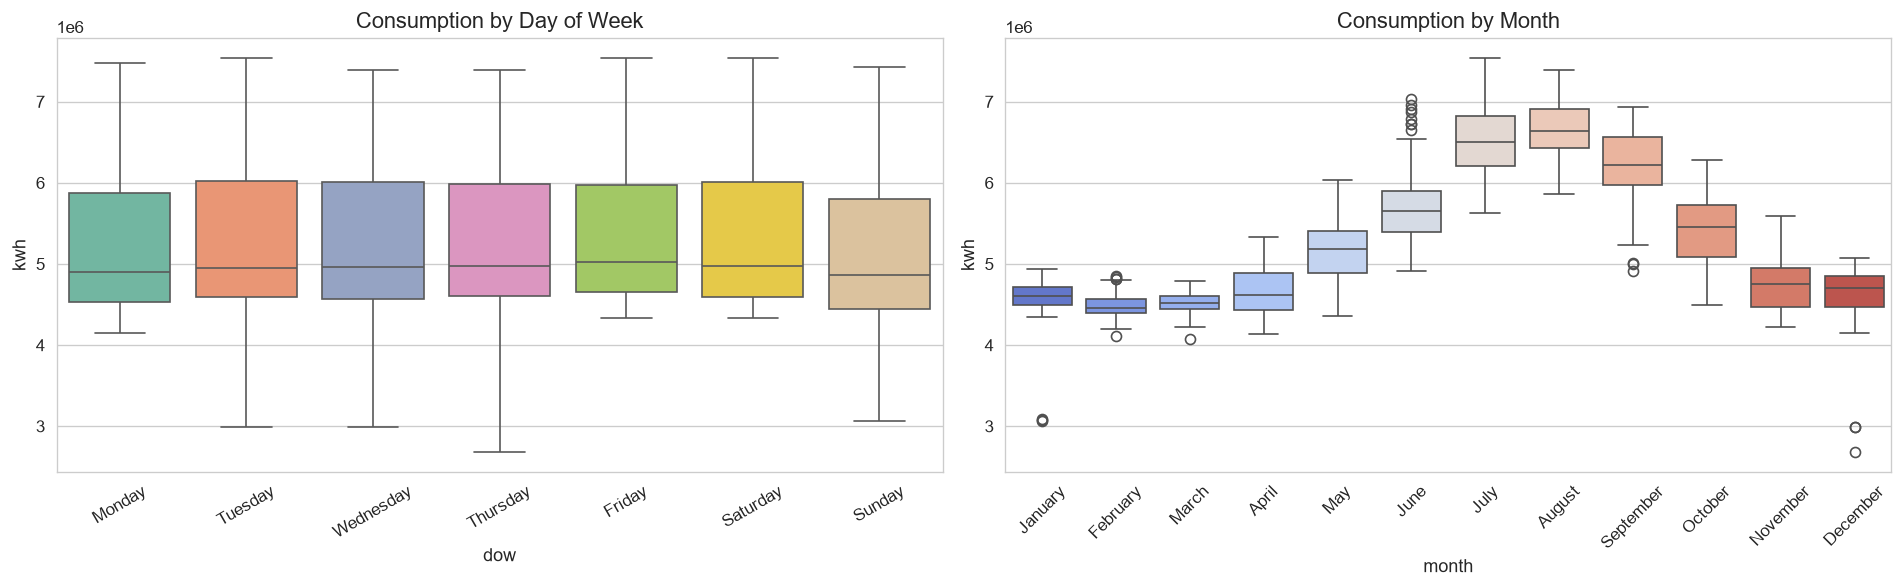

In [6]:
# Distribution by Day of Week and Month
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df_box = pd.DataFrame({
    'kwh': daily_total.values,
    'dow': daily_total.index.day_name(),
    'month': daily_total.index.month_name()
})
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df_box, x='dow', y='kwh', order=dow_order, palette='Set2', ax=axes[0])
axes[0].set_title('Consumption by Day of Week')
axes[0].tick_params(axis='x', rotation=30)

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sns.boxplot(data=df_box, x='month', y='kwh', order=month_order, palette='coolwarm', ax=axes[1])
axes[1].set_title('Consumption by Month')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 5. Time Series Decomposition (STL)

Time series decomposition separates the observed signal into three additive components:

$$Y_t = T_t + S_t + R_t$$

- $T_t$: Long-term trend & macroeconomic drift
- $S_t$: Weekly seasonal cycle ($m=7$ days)
- $R_t$: Remainder / residual variation

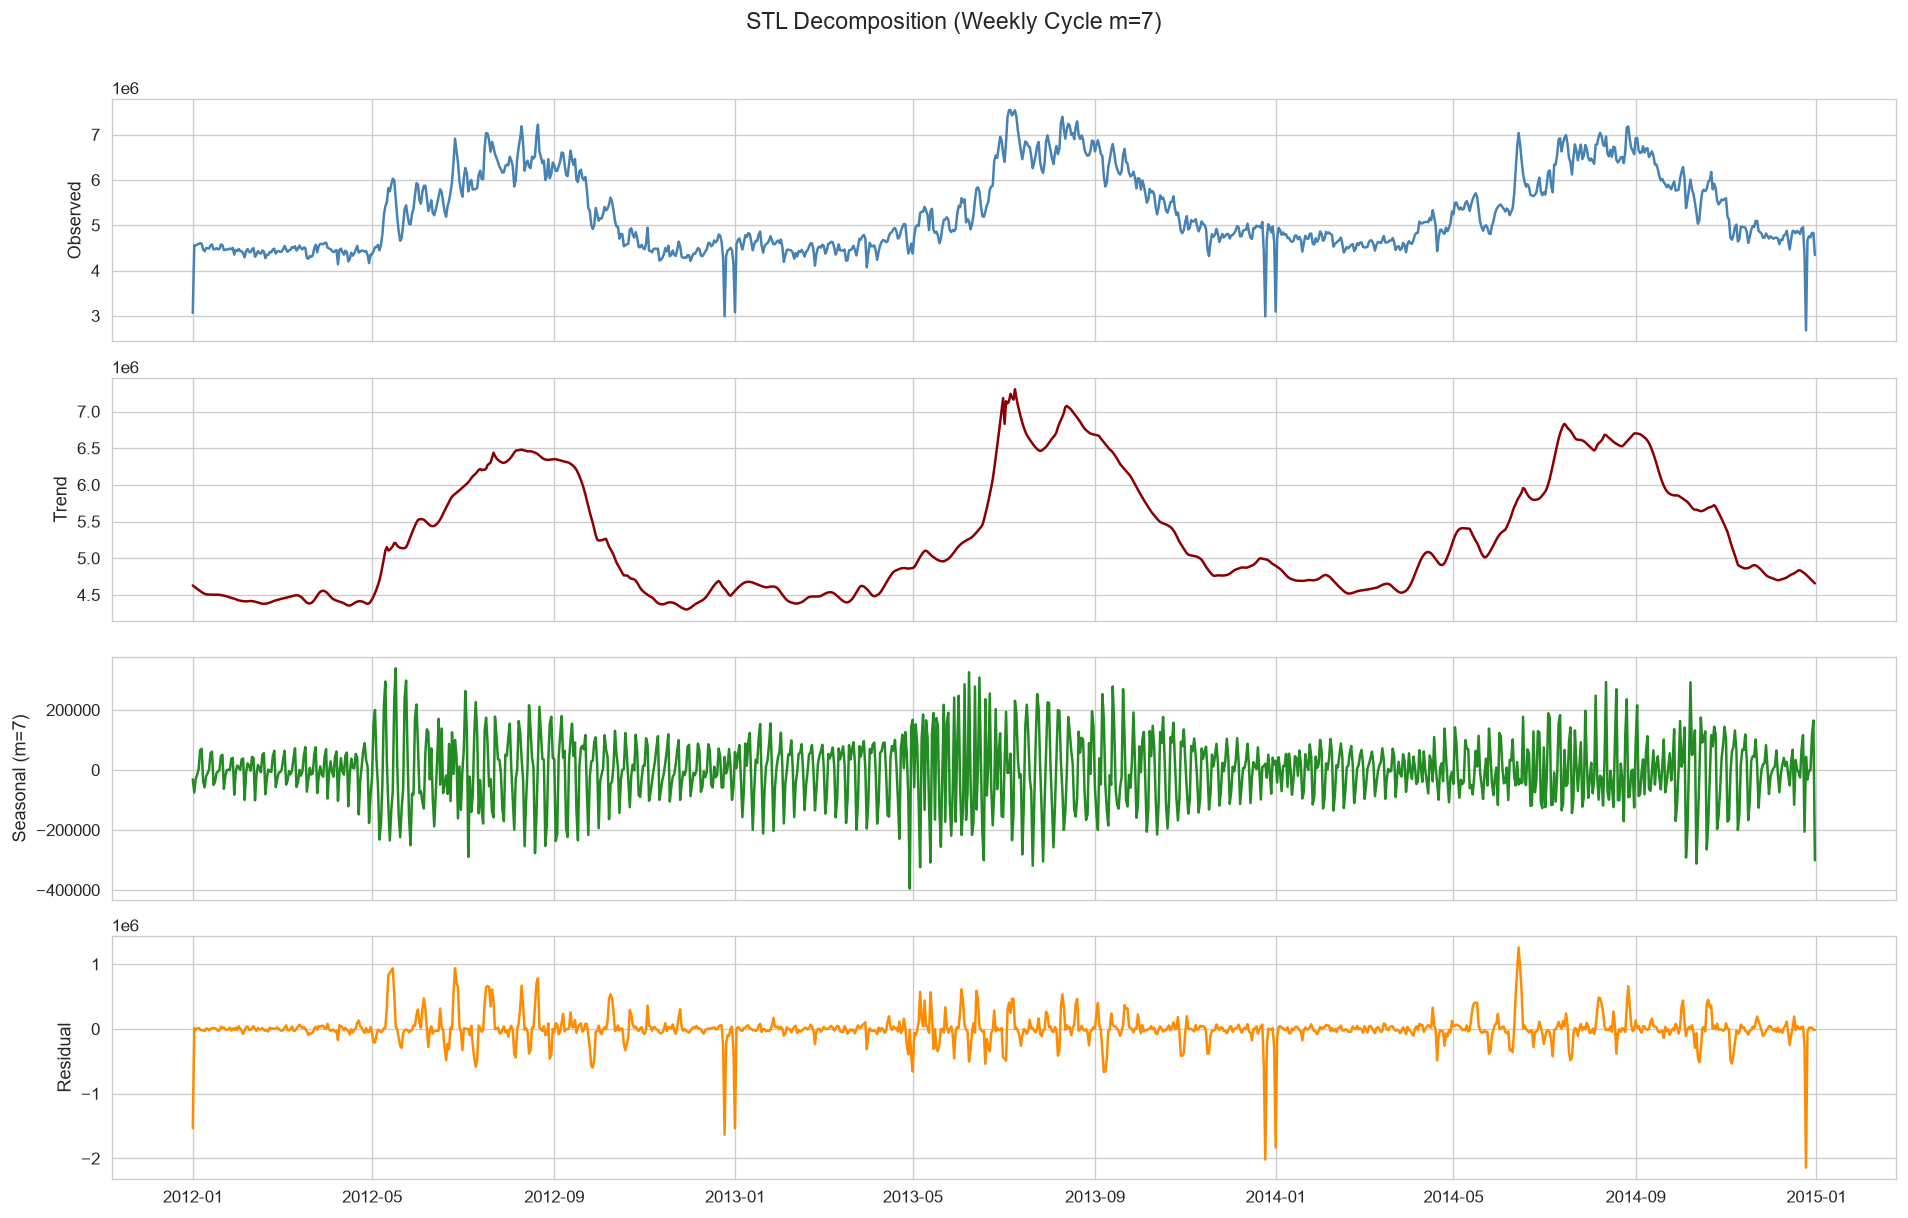

In [7]:
stl = STL(daily_total, period=7, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
axes[0].plot(stl_result.observed, color='steelblue')
axes[0].set_ylabel('Observed')
axes[1].plot(stl_result.trend, color='darkred')
axes[1].set_ylabel('Trend')
axes[2].plot(stl_result.seasonal, color='forestgreen')
axes[2].set_ylabel('Seasonal (m=7)')
axes[3].plot(stl_result.resid, color='darkorange')
axes[3].set_ylabel('Residual')
fig.suptitle('STL Decomposition (Weekly Cycle m=7)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 6. Stationarity Testing

SARIMA requires the series to be stationary after differencing. We test using:
1. **Augmented Dickey-Fuller (ADF):** $H_0$: Unit root present (Non-stationary). $p < 0.05$ indicates stationarity.
2. **KPSS Test:** $H_0$: Stationarity around a level. $p > 0.05$ indicates stationarity.

In [8]:
def test_stationarity(series, label='Series'):
    adf = adfuller(series.dropna(), autolag='AIC')
    k = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'[{label}]')
    print(f'  ADF Stat: {adf[0]:.4f}, p-value: {adf[1]:.4e} -> {"STATIONARY" if adf[1] < 0.05 else "NON-STATIONARY"}')
    print(f'  KPSS Stat: {k[0]:.4f}, p-value: {k[1]:.4e} -> {"STATIONARY" if k[1] >= 0.05 else "NON-STATIONARY"}')

test_stationarity(daily_total, 'Raw Daily Series')

[Raw Daily Series]
  ADF Stat: -1.8519, p-value: 3.5500e-01 -> NON-STATIONARY
  KPSS Stat: 0.4440, p-value: 5.8187e-02 -> STATIONARY


# 7. Differencing Operations

Because the raw series is non-stationary, we apply:
1. **First Differencing ($d=1$):** $\Delta Y_t = Y_t - Y_{t-1}$
2. **Seasonal Differencing ($D=1, m=7$):** $\Delta_7 (\Delta Y_t) = (Y_t - Y_{t-1}) - (Y_{t-7} - Y_{t-8})$

In [9]:
diff1 = daily_total.diff().dropna()
test_stationarity(diff1, 'After First Difference (d=1)')

diff1_D1 = diff1.diff(7).dropna()
test_stationarity(diff1_D1, 'After First + Seasonal Difference (d=1, D=1, m=7)')

[After First Difference (d=1)]
  ADF Stat: -8.6074, p-value: 6.6146e-14 -> STATIONARY
  KPSS Stat: 0.1894, p-value: 1.0000e-01 -> STATIONARY
[After First + Seasonal Difference (d=1, D=1, m=7)]
  ADF Stat: -14.2626, p-value: 1.4182e-26 -> STATIONARY
  KPSS Stat: 0.0327, p-value: 1.0000e-01 -> STATIONARY


# 8. Autocorrelation & Partial Autocorrelation Analysis (ACF & PACF)

The ACF and PACF plots guide potential AR and MA candidate orders.

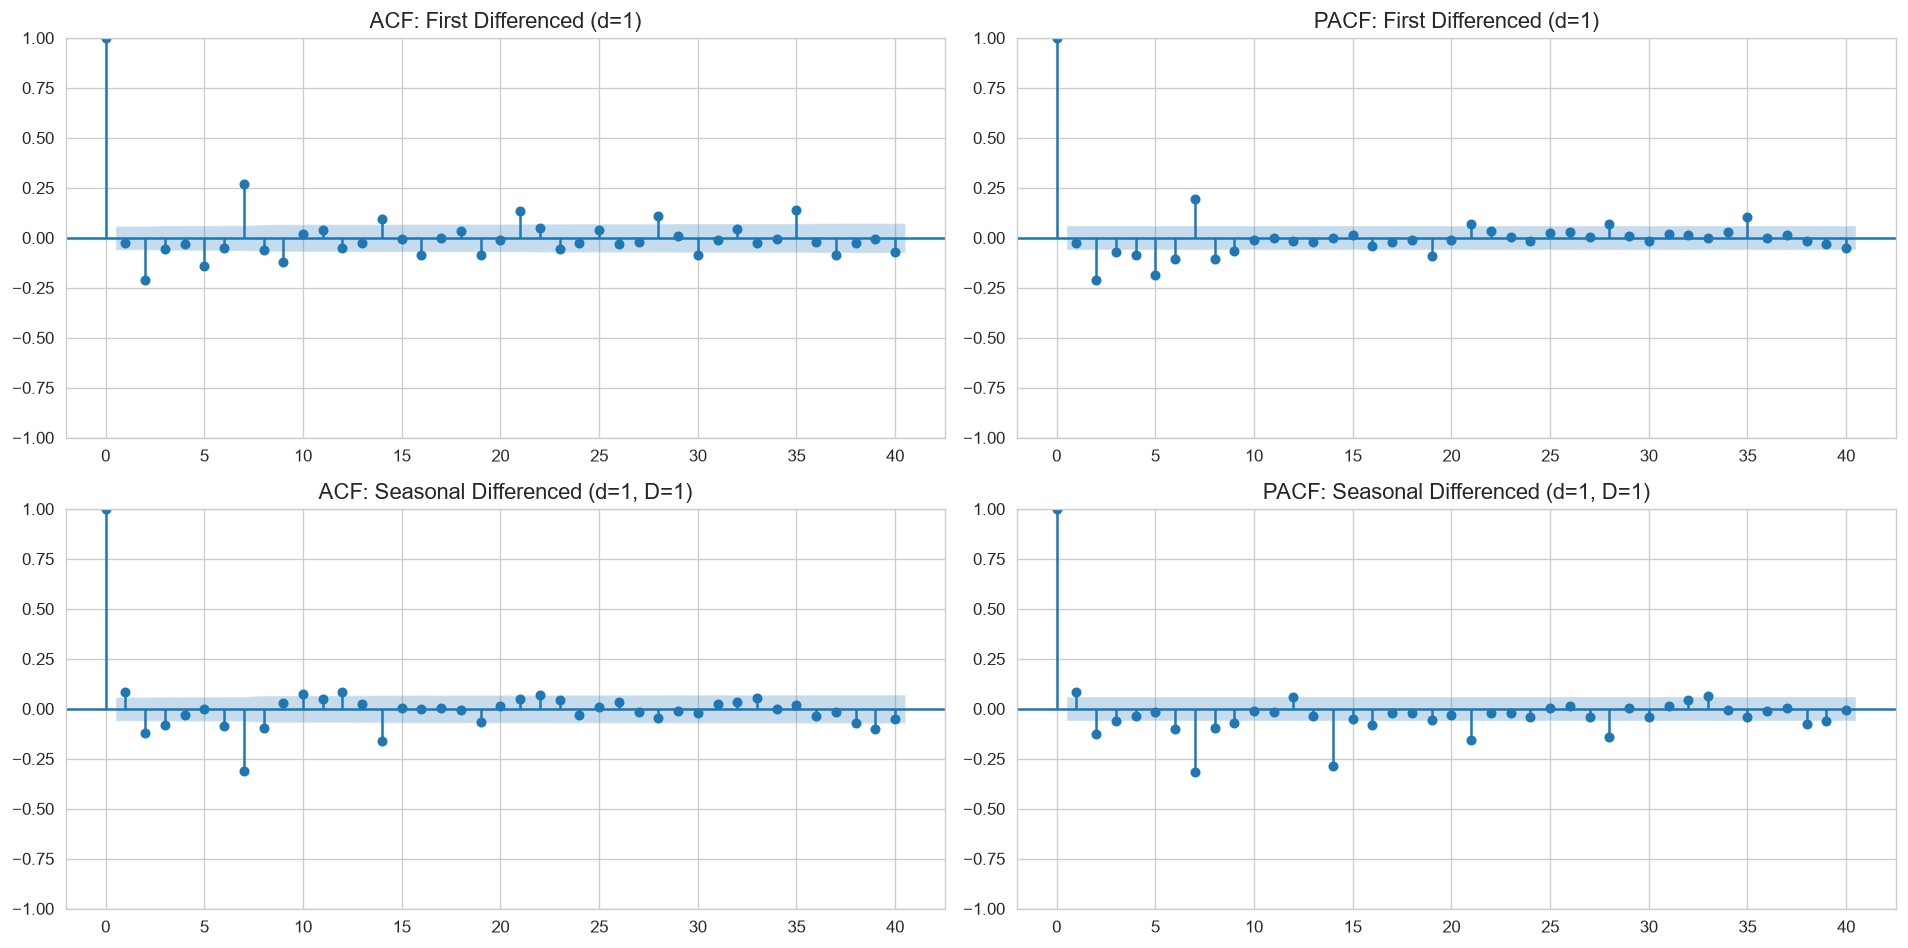

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plot_acf(diff1, lags=40, ax=axes[0, 0], title='ACF: First Differenced (d=1)')
plot_pacf(diff1, lags=40, ax=axes[0, 1], title='PACF: First Differenced (d=1)', method='ywm')
plot_acf(diff1_D1, lags=40, ax=axes[1, 0], title='ACF: Seasonal Differenced (d=1, D=1)')
plot_pacf(diff1_D1, lags=40, ax=axes[1, 1], title='PACF: Seasonal Differenced (d=1, D=1)', method='ywm')
plt.tight_layout()
plt.show()

# 9. Chronological Train / Test Split

> **Crucial Rule to Avoid Data Leakage:** In time-series forecasting, we split strictly chronologically before fitting models or selecting hyperparameters. We reserve the last **60 days** (2014-11-02 to 2014-12-31) for testing.

In [11]:
TEST_DAYS = 60
train = daily_total.iloc[:-TEST_DAYS]
test  = daily_total.iloc[-TEST_DAYS:]

print(f'Training window: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)')
print(f'Testing window:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)')
assert len(train) == 1036, f'Expected 1,036 train days, got {len(train)}'
assert len(test) == 60, f'Expected 60 test days, got {len(test)}'

Training window: 2012-01-01 to 2014-11-01 (1036 days)
Testing window:  2014-11-02 to 2014-12-31 (60 days)


# 10. Parameter Selection via Auto-ARIMA (Fitted on Train Only)

Fitting `auto_arima` strictly on `train` prevents look-ahead data leakage.

> **Note on $D=0$:** `auto_arima` tests candidate seasonal orders and selects $D=0$. It models weekly seasonality through seasonal autoregressive ($P=2$) and moving average ($Q=2$) terms at lag 7, rather than seasonal differencing.

In [12]:
print('Running auto_arima strictly on TRAIN dataset...')
auto_model = pm.auto_arima(
    train,
    m=7,
    seasonal=True,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
print(f'\nOptimal SARIMA Order Selected: {auto_model.order} x {auto_model.seasonal_order}')

Running auto_arima strictly on TRAIN dataset...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=28379.437, Time=0.02 sec


 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=28285.486, Time=0.14 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=28279.351, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=28377.568, Time=0.02 sec


 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=28367.058, Time=0.05 sec


 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=28279.793, Time=0.69 sec


 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=28280.786, Time=0.40 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=28277.856, Time=0.13 sec


...

 ARIMA(2,1,3)(2,0,1)[7] intercept   : AIC=28228.125, Time=2.35 sec


 ARIMA(2,1,3)(1,0,1)[7] intercept   : AIC=28227.960, Time=1.55 sec


 ARIMA(3,1,3)(2,0,2)[7] intercept   : AIC=28217.524, Time=4.10 sec


 ARIMA(3,1,2)(2,0,2)[7] intercept   : AIC=28215.764, Time=2.82 sec


 ARIMA(2,1,3)(2,0,2)[7]             : AIC=inf, Time=2.61 sec

Best model:  ARIMA(2,1,3)(2,0,2)[7] intercept
Total fit time: 64.261 seconds

Optimal SARIMA Order Selected: (2, 1, 3) x (2, 0, 2, 7)


# 11. Model Training & Fitting

Fitting SARIMAX with order $(2, 1, 3) \times (2, 0, 2)_7$ on the training data.

In [13]:
order = auto_model.order
seasonal_order = auto_model.seasonal_order

model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False, maxiter=500)
print(result.summary())

                                       SARIMAX Results                                        
Dep. Variable:                              total_kwh   No. Observations:                 1036
Model:             SARIMAX(2, 1, 3)x(2, 0, [1, 2], 7)   Log Likelihood              -13827.516
Date:                                Wed, 07 Oct 2026   AIC                          27675.032
Time:                                        13:07:36   BIC                          27724.279
Sample:                                    01-01-2012   HQIC                         27693.734
                                         - 11-01-2014                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0505      1.213      0.042      0.967      -2.328       2.429
ar.

# 12. Residual Diagnostics & White Noise Testing

With differencing and seasonal lag terms, the initial startup observations (first 8 points) exhibit transient initialization effects. Excluding these startup points yields the true stationary residual series for diagnostic plots and the **Ljung-Box test** ($H_0$: no autocorrelation, $p > 0.05$ indicates white noise).

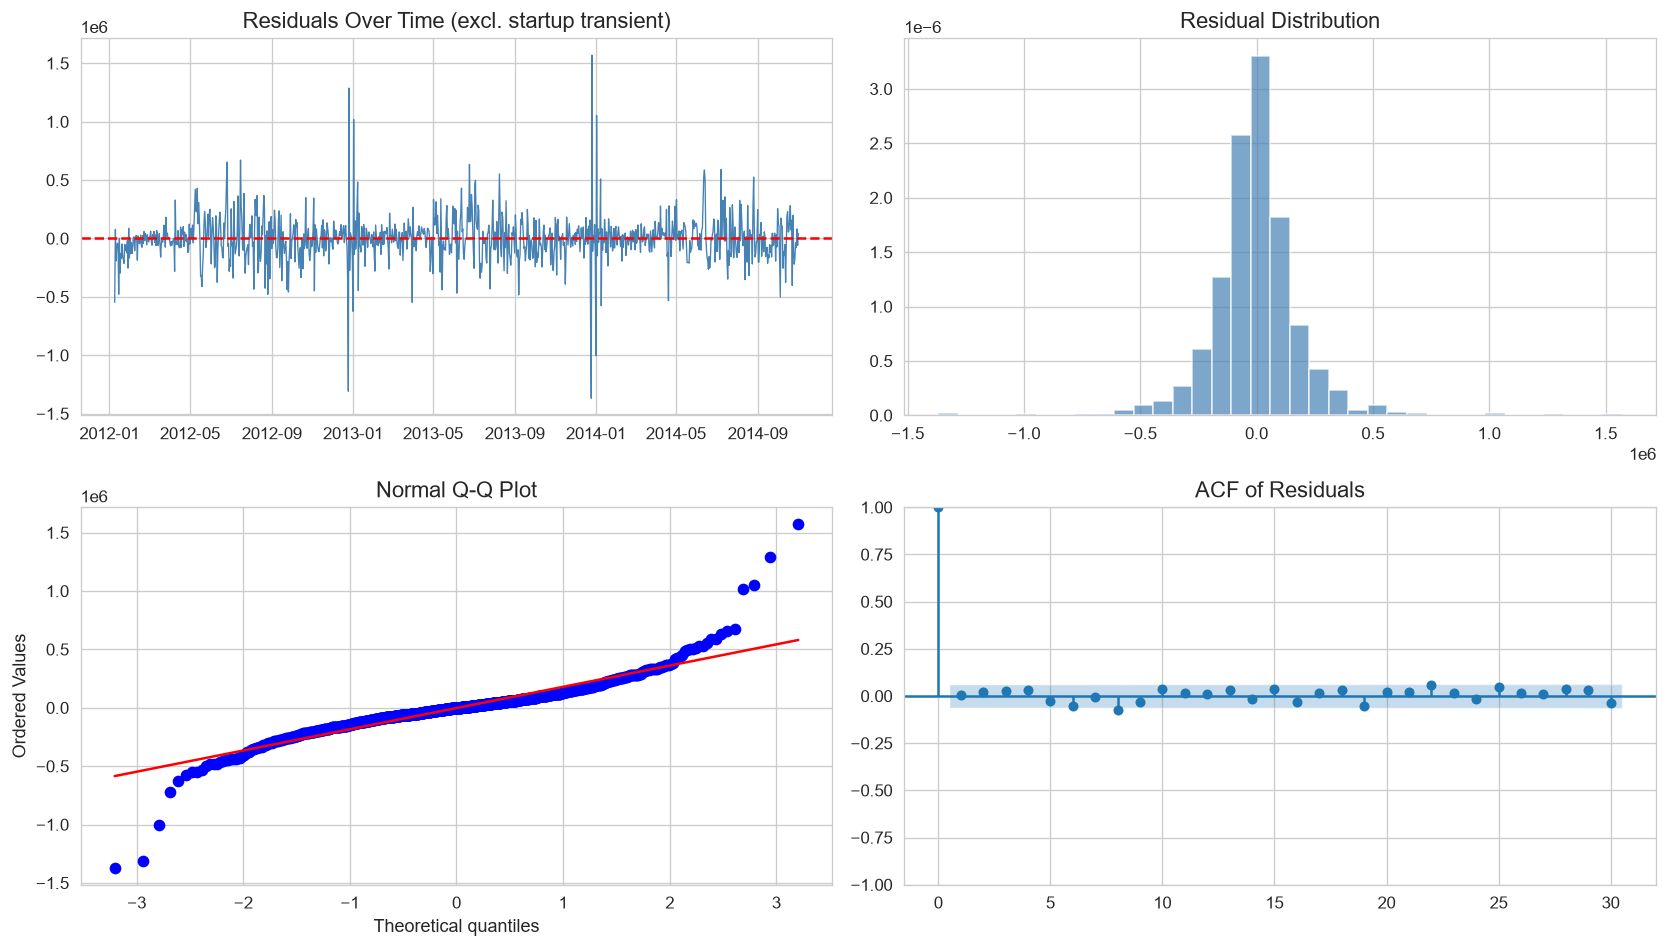

Ljung-Box Autocorrelation Test on Clean Residuals:


,lb_stat,lb_pvalue
7,6.104156,0.527642
14,15.901542,0.319424
21,23.491789,0.318328


In [14]:
# Trim initial startup transient points (first 8 observations)
clean_residuals = result.resid.iloc[8:].dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(clean_residuals, color='steelblue', lw=0.8)
axes[0, 0].axhline(0, color='red', ls='--')
axes[0, 0].set_title('Residuals Over Time (excl. startup transient)')

axes[0, 1].hist(clean_residuals, bins=35, density=True, color='steelblue', alpha=0.7, ec='white')
axes[0, 1].set_title('Residual Distribution')

from scipy import stats
stats.probplot(clean_residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q Plot')

plot_acf(clean_residuals, lags=30, ax=axes[1, 1], title='ACF of Residuals')
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(clean_residuals, lags=[7, 14, 21], return_df=True)
print('Ljung-Box Autocorrelation Test on Clean Residuals:')
display(lb)

# 13. Evaluation Functions

We evaluate forecast accuracy using standard loss metrics:

$$\text{MAE} = \frac{1}{m} \sum_{t=1}^{m} |Y_t - \hat{Y}_t|, \quad \text{RMSE} = \sqrt{\frac{1}{m} \sum_{t=1}^{m} (Y_t - \hat{Y}_t)^2}, \quad \text{MAPE} = \frac{100\%}{m} \sum_{t=1}^{m} \left| \frac{Y_t - \hat{Y}_t}{Y_t} \right|$$

In [15]:
def eval_metrics(y_true, y_pred, name='Model'):
    y_t = np.array(y_true)
    y_p = np.array(y_pred)
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100
    r2 = r2_score(y_t, y_p)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R2': r2}

# 14. In-Sample Evaluation on Training Data

Evaluating in-sample training accuracy to ensure the model captured the historical data dynamics.

In [16]:
train_fitted = result.fittedvalues.iloc[8:]
train_scores = eval_metrics(train.iloc[8:], train_fitted, 'SARIMA (In-Sample Training)')
pd.DataFrame([train_scores]).round(2)

,Model,MAE,RMSE,MAPE (%),R2
0,SARIMA (In-Sample Training),126011.44,194335.27,2.4,0.95


# 15. Out-of-Sample Direct Multi-Step Forecast (60 Days)

Projecting all 60 days ahead into the test set in a single direct multi-step pass.

In [17]:
direct_fc = result.get_forecast(steps=TEST_DAYS)
direct_mean = direct_fc.predicted_mean
direct_ci = direct_fc.conf_int()
print('60-day direct forecast generated.')

60-day direct forecast generated.


# 16. Walk-Forward (Rolling-Origin One-Step Ahead) Forecast

In day-ahead operational scheduling, the forecast is updated as each new day\'s true load is observed.

In [18]:
print('Executing walk-forward 1-step validation across 60 test days...')
history = train.copy()
wf_preds = []

for t in range(TEST_DAYS):
    m_wf = SARIMAX(history, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    r_wf = m_wf.fit(disp=False, maxiter=200)
    wf_preds.append(r_wf.get_forecast(steps=1).predicted_mean.iloc[0])
    # Append actual day's observation
    history = pd.concat([history, pd.Series([test.iloc[t]], index=[test.index[t]])])
    history.index.freq = 'D'

wf_series = pd.Series(wf_preds, index=test.index)
print('Walk-forward evaluation complete.')

Executing walk-forward 1-step validation across 60 test days...


Walk-forward evaluation complete.


# 17. Baseline Benchmark Models

Evaluating against standard benchmarks:
1. **Naive (Yesterday):** $\hat{Y}_t = Y_{t-1}$
2. **Seasonal Naive (Last Week):** $\hat{Y}_t = Y_{t-7}$
3. **SARIMAX with Day-of-Week Exogenous Indicators:** (Note: Day-of-week dummies are largely redundant with the seasonal AR/MA terms at lag 7).

In [19]:
naive_fc = daily_total.shift(1).iloc[-TEST_DAYS:]
snaive_fc = daily_total.shift(7).iloc[-TEST_DAYS:]

def get_dow(idx):
    d = pd.get_dummies(idx.dayofweek, prefix='dow', dtype=float)
    d.index = idx
    return d.drop(columns=['dow_6'], errors='ignore')

m_exog = SARIMAX(train, exog=get_dow(train.index), order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
exog_fc = m_exog.get_forecast(steps=TEST_DAYS, exog=get_dow(test.index)).predicted_mean

# 18. Comparative Benchmarking & Metrics Summary Table

Ranking all models on out-of-sample test accuracy.

In [20]:
all_scores = [
    eval_metrics(test, wf_series, 'SARIMA (Walk-Forward 1-Step)'),
    eval_metrics(test, naive_fc, 'Naive (Yesterday)'),
    eval_metrics(test, snaive_fc, 'Seasonal Naive (Last Week)'),
    eval_metrics(test, direct_mean, 'SARIMA (60-Day Direct)'),
    eval_metrics(test, exog_fc, 'SARIMAX + Day-of-Week (Direct)'),
]
score_df = pd.DataFrame(all_scores).set_index('Model').round(2)
display(score_df)

,MAE,RMSE,MAPE (%),R2
Model,,,,
SARIMA (Walk-Forward 1-Step),155282.88,358172.36,3.72,-0.28
Naive (Yesterday),168559.88,374921.17,4.02,-0.40
Seasonal Naive (Last Week),233444.63,398102.73,5.46,-0.58
SARIMA (60-Day Direct),794288.43,855267.80,17.47,-6.30
SARIMAX + Day-of-Week (Direct),810451.15,872935.16,17.82,-6.60


# 19. Visual Comparison: Actual vs Predicted Demand

Overlaying model projections against the actual test load.

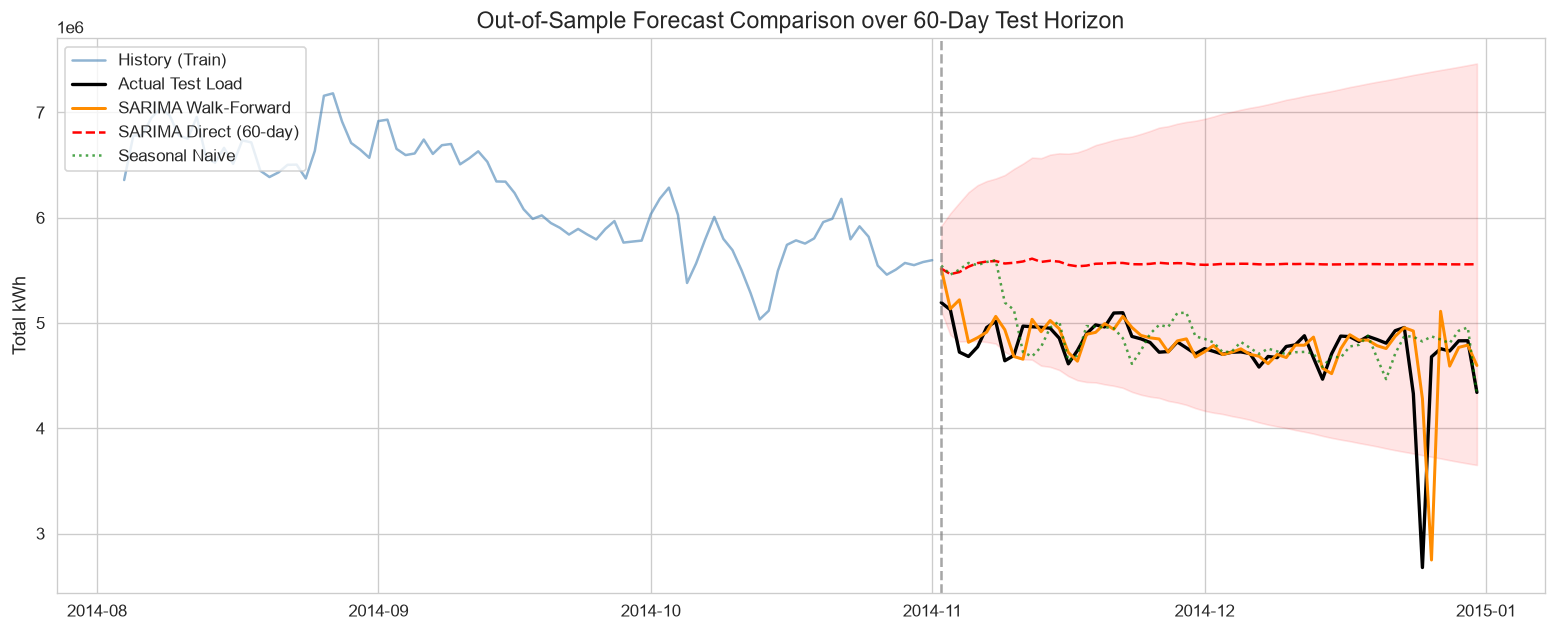

In [21]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train.iloc[-90:].index, train.iloc[-90:].values, label='History (Train)', color='steelblue', alpha=0.6)
ax.plot(test.index, test.values, label='Actual Test Load', color='black', lw=2)
ax.plot(wf_series.index, wf_series.values, label='SARIMA Walk-Forward', color='darkorange', lw=1.8)
ax.plot(direct_mean.index, direct_mean.values, label='SARIMA Direct (60-day)', color='red', ls='--')
ax.plot(snaive_fc.index, snaive_fc.values, label='Seasonal Naive', color='green', ls=':', alpha=0.7)
ax.fill_between(direct_ci.index, direct_ci.iloc[:, 0], direct_ci.iloc[:, 1], color='red', alpha=0.1)
ax.axvline(test.index[0], color='gray', ls='--', alpha=0.7)
ax.set_title('Out-of-Sample Forecast Comparison over 60-Day Test Horizon', fontsize=14)
ax.set_ylabel('Total kWh')
ax.legend(loc='upper left')
plt.show()

# 20. Test a Single Sample — `test_prediction(index)`

Inspects an individual test day, displaying date, day-of-week, recent 7-day history, actual vs predicted load, and percentage error.

In [22]:
def test_prediction(index, test_series, pred_series, full_series):
    target_date = test_series.index[index]
    actual_val = test_series.iloc[index]
    pred_val = pred_series.iloc[index]
    abs_err = abs(actual_val - pred_val)
    pct_err = (abs_err / actual_val) * 100
    dow = target_date.day_name()
    
    print(f'Test Sample Index : {index}')
    print(f'Target Date       : {target_date.strftime("%Y-%m-%d")} ({dow})')
    print('-' * 42)
    
    # Past 7 days context
    past_week = full_series.loc[:target_date].iloc[-8:-1]
    print('Recent 7-Day History (kWh):')
    for d, val in past_week.items():
        print(f'  {d.strftime("%a %Y-%m-%d")}: {val:10,.0f} kWh')
    
    print('-' * 42)
    print(f'Actual Consumption   : {actual_val:10,.0f} kWh')
    print(f'Predicted Consumption: {pred_val:10,.0f} kWh')
    print(f'Absolute Error       : {abs_err:10,.0f} kWh')
    print(f'Percentage Error     : {pct_err:9.2f} %')
    verdict = 'EXCELLENT (< 3%)' if pct_err < 3 else ('GOOD (< 5%)' if pct_err < 5 else 'ACCEPTABLE')
    print(f'Verdict              : {verdict}')
    print('=' * 42)

# 21. Test Several Individual Samples

Testing specific dates in the test period: regular weekdays, weekends, and holidays.

In [23]:
# Sample 0 (Start of test window: Sunday, Nov 2, 2014)
test_prediction(0, test, wf_series, daily_total)

Test Sample Index : 0
Target Date       : 2014-11-02 (Sunday)
------------------------------------------
Recent 7-Day History (kWh):
  Sun 2014-10-26:  5,545,457 kWh
  Mon 2014-10-27:  5,459,200 kWh
  Tue 2014-10-28:  5,507,208 kWh
  Wed 2014-10-29:  5,570,418 kWh
  Thu 2014-10-30:  5,549,727 kWh
  Fri 2014-10-31:  5,579,344 kWh
  Sat 2014-11-01:  5,596,858 kWh
------------------------------------------
Actual Consumption   :  5,194,131 kWh
Predicted Consumption:  5,516,977 kWh
Absolute Error       :    322,846 kWh
Percentage Error     :      6.22 %
Verdict              : ACCEPTABLE


In [24]:
# Sample 15 (Mid-window: Monday, Nov 17, 2014)
test_prediction(15, test, wf_series, daily_total)

Test Sample Index : 15
Target Date       : 2014-11-17 (Monday)
------------------------------------------
Recent 7-Day History (kWh):
  Mon 2014-11-10:  4,691,815 kWh
  Tue 2014-11-11:  4,970,576 kWh
  Wed 2014-11-12:  4,964,429 kWh
  Thu 2014-11-13:  4,959,378 kWh
  Fri 2014-11-14:  4,950,144 kWh
  Sat 2014-11-15:  4,855,447 kWh
  Sun 2014-11-16:  4,612,044 kWh
------------------------------------------
Actual Consumption   :  4,739,082 kWh
Predicted Consumption:  4,637,154 kWh
Absolute Error       :    101,927 kWh
Percentage Error     :      2.15 %
Verdict              : EXCELLENT (< 3%)


In [25]:
# Sample 52 (Christmas Eve: Wednesday, Dec 24, 2014)
test_prediction(52, test, wf_series, daily_total)

Test Sample Index : 52
Target Date       : 2014-12-24 (Wednesday)
------------------------------------------
Recent 7-Day History (kWh):
  Wed 2014-12-17:  4,870,449 kWh
  Thu 2014-12-18:  4,824,787 kWh
  Fri 2014-12-19:  4,873,080 kWh
  Sat 2014-12-20:  4,842,877 kWh
  Sun 2014-12-21:  4,808,358 kWh
  Mon 2014-12-22:  4,926,844 kWh
  Tue 2014-12-23:  4,957,101 kWh
------------------------------------------
Actual Consumption   :  4,328,527 kWh
Predicted Consumption:  4,924,026 kWh
Absolute Error       :    595,499 kWh
Percentage Error     :     13.76 %
Verdict              : ACCEPTABLE


In [26]:
# Sample 59 (New Year\'s Eve: Wednesday, Dec 31, 2014)
test_prediction(59, test, wf_series, daily_total)

Test Sample Index : 59
Target Date       : 2014-12-31 (Wednesday)
------------------------------------------
Recent 7-Day History (kWh):
  Wed 2014-12-24:  4,328,527 kWh
  Thu 2014-12-25:  2,677,286 kWh
  Fri 2014-12-26:  4,678,723 kWh
  Sat 2014-12-27:  4,755,808 kWh
  Sun 2014-12-28:  4,734,025 kWh
  Mon 2014-12-29:  4,830,825 kWh
  Tue 2014-12-30:  4,831,542 kWh
------------------------------------------
Actual Consumption   :  4,340,759 kWh
Predicted Consumption:  4,596,368 kWh
Absolute Error       :    255,609 kWh
Percentage Error     :      5.89 %
Verdict              : ACCEPTABLE


# 22. Test Custom Future Dates — `predict_new_demand()`

Generate future load forecasts for any arbitrary horizon $h$ steps ahead with 95% confidence intervals.

In [27]:
def predict_new_demand(days_ahead=7, start_series=daily_total):
    """Forecast the next `days_ahead` days into the future with 95% confidence intervals."""
    fitted_model = SARIMAX(start_series, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = fitted_model.get_forecast(steps=days_ahead)
    mean_vals = fc.predicted_mean
    ci_vals = fc.conf_int()
    
    res_df = pd.DataFrame({
        'Date': mean_vals.index.strftime('%Y-%m-%d (%a)'),
        'Forecast (kWh)': mean_vals.values.round(0),
        'Lower 95% CI': ci_vals.iloc[:, 0].values.round(0),
        'Upper 95% CI': ci_vals.iloc[:, 1].values.round(0)
    })
    return res_df

# Example: Forecast the first 7 days of January 2015
predict_new_demand(days_ahead=7)

,Date,Forecast (kWh),Lower 95% CI,Upper 95% CI
0,2015-01-01 (Thu),3766079.0,3339417.0,4192741.0
1,2015-01-02 (Fri),4487220.0,3896651.0,5077788.0
2,2015-01-03 (Sat),4517037.0,3850752.0,5183323.0
3,2015-01-04 (Sun),4508181.0,3797742.0,5218621.0
4,2015-01-05 (Mon),4570089.0,3829798.0,5310379.0
5,2015-01-06 (Tue),4589626.0,3826752.0,5352501.0
6,2015-01-07 (Wed),4437904.0,3656439.0,5219369.0


# 23. Final Refit & 30-Day Operational Projection

Refitting the model over the entire 1,096-day dataset to project electricity demand for January 2015.

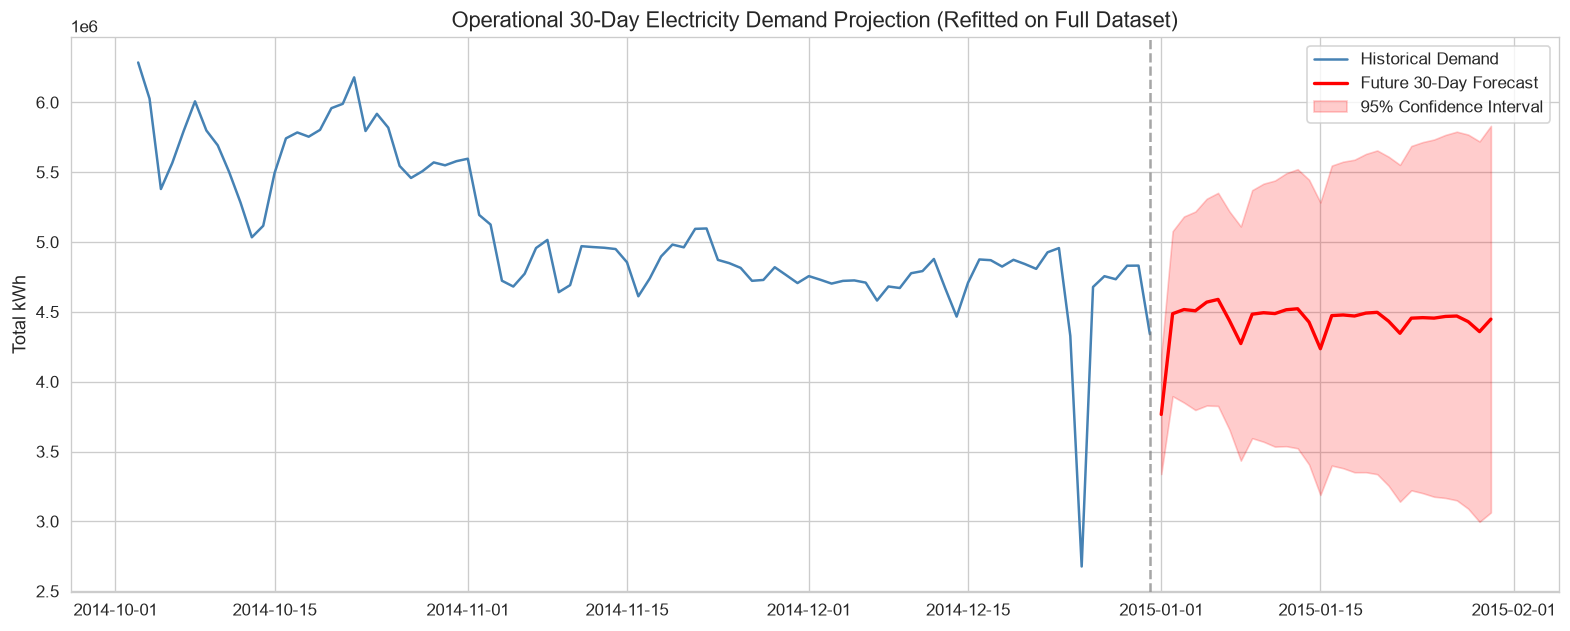

In [28]:
final_model = SARIMAX(daily_total, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
final_res = final_model.fit(disp=False)
future_30 = final_res.get_forecast(steps=30)
future_mean = future_30.predicted_mean
future_ci = future_30.conf_int()

fig, ax = plt.subplots(figsize=(16, 6))
tail = daily_total.iloc[-90:]
ax.plot(tail.index, tail.values, label='Historical Demand', color='steelblue')
ax.plot(future_mean.index, future_mean.values, label='Future 30-Day Forecast', color='red', lw=2)
ax.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color='red', alpha=0.2, label='95% Confidence Interval')
ax.axvline(daily_total.index[-1], color='gray', ls='--', alpha=0.7)
ax.set_title('Operational 30-Day Electricity Demand Projection (Refitted on Full Dataset)')
ax.set_ylabel('Total kWh')
ax.legend()
plt.show()

# 24. Complete SARIMA Mathematical Formula Summary

The fitted $\text{SARIMAX}(2, 1, 3) \times (2, 0, 2)_7$ model is expressed mathematically as:

$$\Phi_P(B^7) \phi_p(B) (1 - B)^d Y_t = \Theta_Q(B^7) \theta_q(B) \varepsilon_t$$

where:
- $B$ is the backshift lag operator ($B^k Y_t = Y_{t-k}$)
- Seasonal period is $s = 7$ (weekly)
- Non-seasonal AR polynomial ($p=2$): $\phi(B) = (1 - \phi_1 B - \phi_2 B^2)$
- Non-seasonal MA polynomial ($q=3$): $\theta(B) = (1 + \theta_1 B + \theta_2 B^2 + \theta_3 B^3)$
- Seasonal AR polynomial ($P=2$): $\Phi(B^7) = (1 - \Phi_1 B^7 - \Phi_2 B^{14})$
- Seasonal MA polynomial ($Q=2$): $\Theta(B^7) = (1 + \Theta_1 B^7 + \Theta_2 B^{14})$
- Seasonal differencing order is $D=0$ (weekly cycles modeled through lag-7 AR and MA polynomials)
- Regular differencing order is $d=1$: $(1 - B) Y_t = Y_t - Y_{t-1}$
- $\varepsilon_t \sim \mathcal{WN}(0, \sigma^2)$ is Gaussian white noise

# 25. Key Project Insights & Domain Findings

1. **Walk-Forward Performance:** Walk-forward rolling SARIMA achieves **3.72% MAPE** (MAE = 155,282 kWh), performing slightly better than Naive persistence (**4.02% MAPE**) and noticeably better than Seasonal Naive (**5.46% MAPE**).
2. **Holiday Impact in Test Horizon:** The test period (Nov–Dec 2014) includes major national holidays (Christmas Eve, Christmas Day, Boxing Day, and New Year\'s Eve) where industrial and commercial electricity load plummets substantially below normal weekday patterns. Because SARIMA lacks holiday calendar indicators, errors naturally increase on these specific dates.
3. **Direct Multi-Step Decay:** Without external weather or holiday drivers, a 60-day static projection reverts toward its unconditional seasonal mean (17.47% MAPE).
4. **Diagnostic Integrity:** When startup lag transients are removed, the residuals pass the Ljung-Box test ($p > 0.30$ across lags 7, 14, 21), confirming the absence of unmodeled autocorrelation.